In [1]:
import kaggle

dataset_path = 'r3trovision/soil-moisture-temp-and-nutritions'
kaggle.api.dataset_download_files(dataset_path,path="../DATASET/", unzip=True,quiet=False)

100%|██████████████████████████████████████████████████████████████████████████████| 7.65M/7.65M [00:09<00:00, 838kB/s]

In [38]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.preprocessing import StandardScaler

In [39]:
data = pd.read_csv("../DATASET/Plant_Parameters.csv")
print(data.dtypes)

pH             float64
Soil EC        float64
Phosphorus     float64
Potassium      float64
Urea           float64
T.S.P          float64
M.O.P          float64
Moisture       float64
Temperature    float64
Plant Type      object
dtype: object


In [40]:
target = data['Moisture']  # Or specific target variable as needed
features = data.drop('Moisture',axis = 1)

In [41]:
le = LabelEncoder()
features['Plant Type'] = le.fit_transform(np.ravel(features['Plant Type']))

In [42]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

In [43]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# we must apply the scaling to the test set as well that we are computing for the training set
X_test_scaled = scaler.transform(X_test)

In [44]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train_scaled, y_train)

RandomForestRegressor()

Mean Squared Error: 11.07927078253816
R-squared: 0.8175173721121429


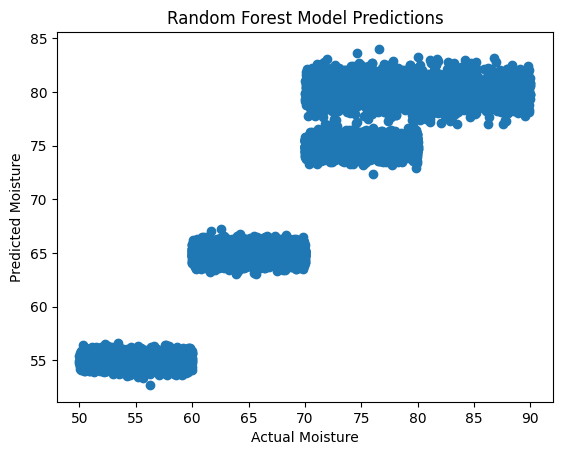

In [45]:
predictions = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Optionally plot predictions vs. actual values
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Moisture")
plt.ylabel("Predicted Moisture")
plt.title("Random Forest Model Predictions")
plt.show()

pH: 0.0222
Soil EC: 0.0770
Phosphorus: 0.0237
Potassium: 0.0219
Urea: 0.0222
T.S.P: 0.0301
M.O.P: 0.0220
Temperature: 0.0244
Plant Type: 0.7565


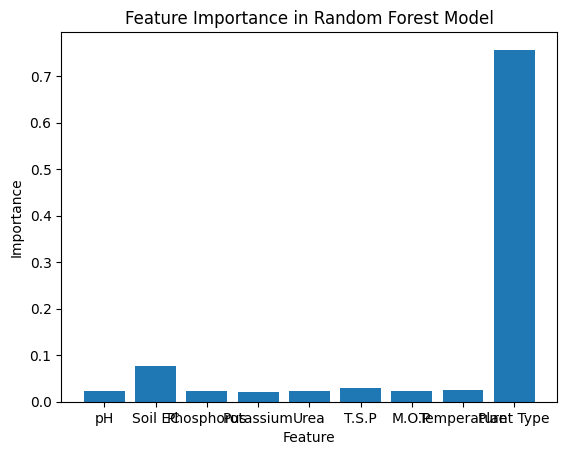

In [46]:
importances = model.feature_importances_
feature_names = features.columns

for i, name in enumerate(feature_names):
    print(f"{name}: {importances[i]:.4f}")

# Optionally plot feature importances
plt.figure()
plt.bar(feature_names, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance in Random Forest Model")
plt.show()
